In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

def scrape_export_table(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')
    
    # Target the Export Data table
    table = soup.find('table') 
    headers = [th.text.strip() for th in table.find_all('th')]
    
    rows = []
    current_item = ""
  
    for tr in table.find_all('tr')[1:]:
        cols = tr.find_all('td')
        if not cols: continue
        
        # If the first cell has text, it's a new Item name
        if cols[0].text.strip():
            current_item = cols[0].text.strip()
            
        metric_type = cols[1].text.strip() # Q, V, or $
        values = [c.text.strip().replace(',', '') for c in cols[2:]]
        
        # Flatten into a format: [Item, Metric, 2015-16, ..., 2024-25]
        rows.append([current_item, metric_type] + values)

    export_df = pd.DataFrame(rows, columns=['Item', 'Metric'] + headers[2:])
    return export_df

export_df = scrape_export_table("https://mpeda.gov.in/?page_id=438&utm_source=chatgpt.com")
export_df

,Item,Metric,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25
0,FROZEN SHRIMP,Q:,373866,434486,565980,614145,652253,590275,728123,711099,716004,741529
1,FROZEN SHRIMP,V:,20045.5,24711.32,30868.17,31800.51,34152.03,32520.29,42706.04,43135.58,40013.54,43334.25
2,FROZEN SHRIMP,$:,3096.68,3726.38,4848.19,4610.59,4889.12,4426.19,5828.59,5481.63,4881.27,5177.01
3,FROZEN FISH,Q:,228749,296762,353192,338933,223318,188130,226586,368549,381588,339692
4,FROZEN FISH,V:,3462.25,4460.9,4674.03,4916.82,3610.01,2941.65,3471.91,5503.18,5509.69,5212.12
5,FROZEN FISH,$:,529.85,672.47,733.17,699.09,513.6,402.31,471.45,687.05,671.17,622.60
6,FR CUTTLE FISH,Q:,65596,63320,69183,60210,70906,59292,58992,54919,54316,59264
7,FR CUTTLE FISH,V:,1636.11,1944.5,2356.46,1975.97,2009.79,1626.34,2062.63,2353.34,2252.63,2394.26
8,FR CUTTLE FISH,$:,250.31,292.73,369.88,282.29,286.4,221.97,280.08,295.49,274.62,285.57
9,FR SQUID,Q:,81769,99348,100845,101101,87631,61176,75750,83846,93509,90370


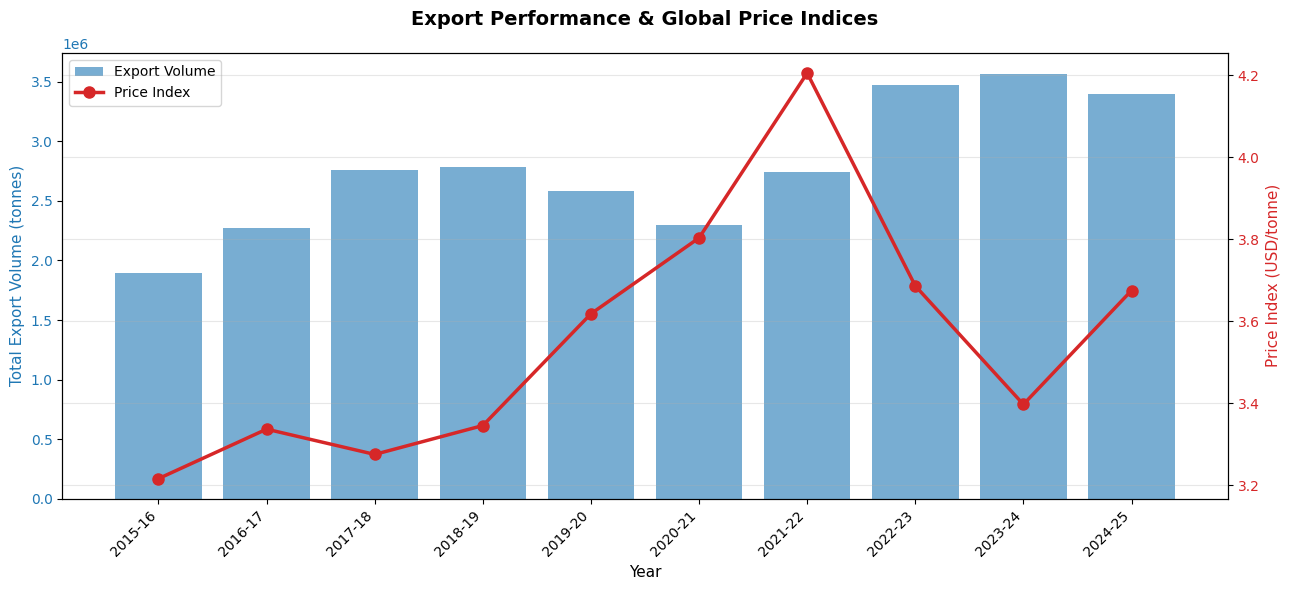


EXPORT PERFORMANCE & GLOBAL PRICE INDICES SUMMARY

Total Export Volume by Year (tonnes):
2015-16    1891784
2016-17    2269895
2017-18    2754488
2018-19    2785117
2019-20    2579303
2020-21    2299020
2021-22    2738529
2022-23    3470572
2023-24    3563204
2024-25    3396341

Price Index by Year (USD/tonne):
2015-16    3.22
2016-17    3.34
2017-18    3.28
2018-19    3.35
2019-20    3.62
2020-21    3.80
2021-22    4.21
2022-23    3.69
2023-24    3.40
2024-25    3.68


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get year columns
years = [col for col in export_df.columns if col not in ['Item', 'Metric']]

# Separate data by metric type and convert to numeric
quantity_data = export_df[export_df['Metric'] == 'Q:'].set_index('Item')
value_data = export_df[export_df['Metric'] == 'V:'].set_index('Item')
price_data = export_df[export_df['Metric'] == '$:'].set_index('Item')

# Convert to numeric (replace non-numeric with NaN)
for df in [quantity_data, value_data, price_data]:
    for col in years:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Calculate totals by year
total_quantity = quantity_data[years].sum()
total_value = value_data[years].sum()

# Calculate price index (average price per unit in USD/tonne)
price_index = (total_value / total_quantity * 100).astype(float)

# Create dual-axis chart
fig, ax1 = plt.subplots(figsize=(13, 6))

# Export Performance - Total Quantity (left axis)
color1 = 'tab:blue'
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Total Export Volume (tonnes)', color=color1, fontsize=11)
bars = ax1.bar(range(len(total_quantity)), total_quantity.values, alpha=0.6, color=color1, label='Export Volume')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range(len(years)))
ax1.set_xticklabels(years, rotation=45, ha='right')

# Global Price Index (right axis)
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Price Index (USD/tonne)', color=color2, fontsize=11)
line = ax2.plot(range(len(price_index)), price_index.values, color=color2, marker='o', linewidth=2.5, markersize=8, label='Price Index')
ax2.tick_params(axis='y', labelcolor=color2)

# Title and legend
plt.title('Export Performance & Global Price Indices', fontsize=14, fontweight='bold', pad=20)
fig.tight_layout()

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.grid(True, alpha=0.3, axis='y')
plt.show()

print("\n" + "="*60)
print("EXPORT PERFORMANCE & GLOBAL PRICE INDICES SUMMARY")
print("="*60)
print("\nTotal Export Volume by Year (tonnes):")
print(total_quantity.round(0).to_string())
print("\nPrice Index by Year (USD/tonne):")
print(price_index.round(2).to_string())

In [8]:
# Create a combined DataFrame for Google Sheets export
export_data = pd.DataFrame({
    'Year': total_quantity.index,
    'Total Export Volume (tonnes)': total_quantity.values,
    'Price Index (USD/tonne)': price_index.values
})

# Export to CSV
csv_filename = 'export_performance_data.csv'
export_data.to_csv(csv_filename, index=False)

print(f"✓ Data exported to '{csv_filename}'")
print("\nData Preview:")
print(export_data.to_string(index=False))
print(f"\n📋 File ready to upload to Google Sheets!")
print(f"   Location: {csv_filename}")


✓ Data exported to 'export_performance_data.csv'

Data Preview:
   Year  Total Export Volume (tonnes)  Price Index (USD/tonne)
2015-16                       1891784                 3.216100
2016-17                       2269895                 3.336798
2017-18                       2754488                 3.275156
2018-19                       2785117                 3.345595
2019-20                       2579303                 3.618253
2020-21                       2299020                 3.803445
2021-22                       2738529                 4.205650
2022-23                       3470572                 3.686375
2023-24                       3563204                 3.397161
2024-25                       3396341                 3.675041

📋 File ready to upload to Google Sheets!
   Location: export_performance_data.csv


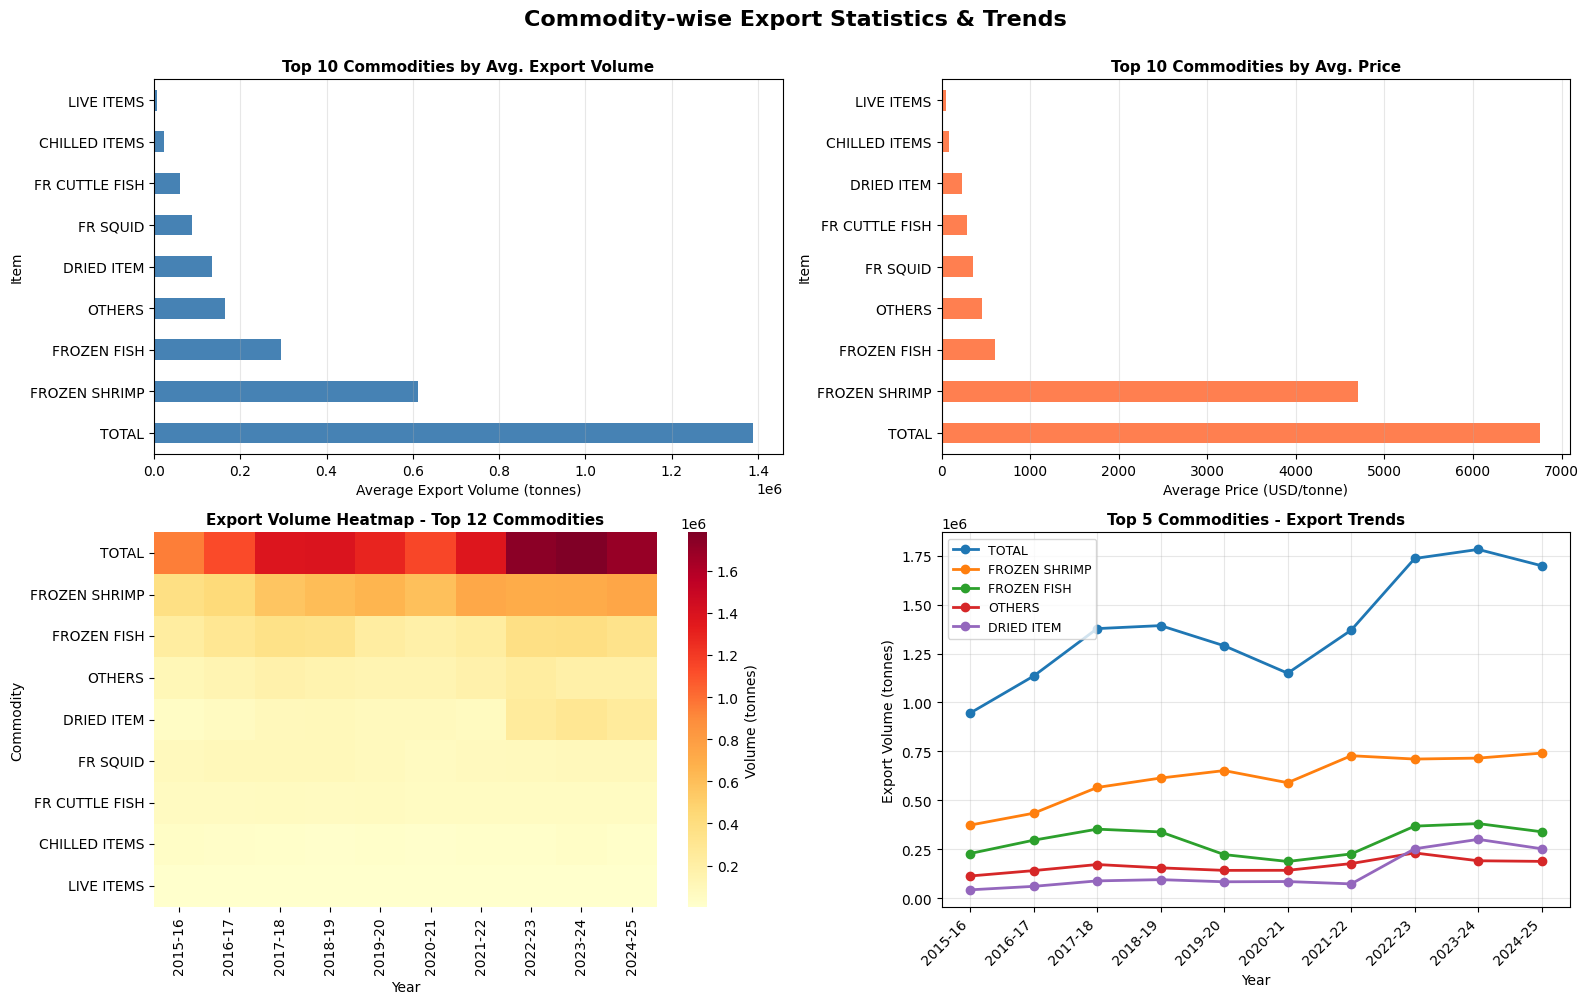


COMMODITY-WISE EXPORT STATISTICS SUMMARY

📊 TOP 10 COMMODITIES BY AVERAGE EXPORT VOLUME:
Item
TOTAL             1387413.0
FROZEN SHRIMP      612776.0
FROZEN FISH        294550.0
OTHERS             165840.0
DRIED ITEM         133927.0
FR SQUID            87534.0
FR CUTTLE FISH      61600.0
CHILLED ITEMS       24128.0
LIVE ITEMS           7057.0


💰 TOP 10 COMMODITIES BY AVERAGE PRICE:
Item
TOTAL             6760.07
FROZEN SHRIMP     4696.57
FROZEN FISH        600.28
OTHERS             453.07
FR SQUID           354.76
FR CUTTLE FISH     283.93
DRIED ITEM         232.67
CHILLED ITEMS       89.07
LIVE ITEMS          49.73


📈 GROWTH ANALYSIS - TOP 5 COMMODITIES (2015-16 to 2024-25):
Item
TOTAL             79.53
FROZEN SHRIMP     98.34
FROZEN FISH       48.50
OTHERS            65.49
DRIED ITEM       483.91


In [9]:
# Commodity-wise Analysis
import seaborn as sns

# Get unique commodities (Items)
commodities = quantity_data.index.tolist()

# Create a figure with commodity export trends
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Commodity-wise Export Statistics & Trends', fontsize=16, fontweight='bold', y=1.00)

# 1. Top 10 Commodities by Average Export Volume
ax = axes[0, 0]
avg_quantity = quantity_data[years].mean(axis=1).sort_values(ascending=False).head(10)
avg_quantity.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Average Export Volume (tonnes)', fontsize=10)
ax.set_title('Top 10 Commodities by Avg. Export Volume', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 2. Top 10 Commodities by Average Price
ax = axes[0, 1]
avg_price = price_data[years].mean(axis=1).sort_values(ascending=False).head(10)
avg_price.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Average Price (USD/tonne)', fontsize=10)
ax.set_title('Top 10 Commodities by Avg. Price', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 3. Heatmap of Commodity Export Volumes
ax = axes[1, 0]
# Show top 12 commodities for clarity
top_commodities = quantity_data.loc[avg_quantity.index[:12]]
sns.heatmap(top_commodities[years], annot=False, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Volume (tonnes)'})
ax.set_title('Export Volume Heatmap - Top 12 Commodities', fontsize=11, fontweight='bold')
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Commodity', fontsize=10)

# 4. Line chart of top 5 commodities
ax = axes[1, 1]
top_5_commodities = avg_quantity.head(5).index
for commodity in top_5_commodities:
    ax.plot(years, quantity_data.loc[commodity, years], marker='o', label=commodity, linewidth=2)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Export Volume (tonnes)', fontsize=10)
ax.set_title('Top 5 Commodities - Export Trends', fontsize=11, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*70)
print("COMMODITY-WISE EXPORT STATISTICS SUMMARY")
print("="*70)

print("\n📊 TOP 10 COMMODITIES BY AVERAGE EXPORT VOLUME:")
print(avg_quantity.round(0).to_string())

print("\n\n💰 TOP 10 COMMODITIES BY AVERAGE PRICE:")
print(avg_price.round(2).to_string())

# Growth analysis for top 5
print("\n\n📈 GROWTH ANALYSIS - TOP 5 COMMODITIES (2015-16 to 2024-25):")
top_5_data = quantity_data.loc[top_5_commodities]
growth_pct = ((top_5_data[years[-1]] - top_5_data[years[0]]) / top_5_data[years[0]] * 100).round(2)
print(growth_pct.to_string())
